# Lecture 06: Neural Networks

**Slides:** `06_Neural_Networks.pdf`

## What you will learn
- Perceptron / logistic-style building blocks
- A simple feed-forward neural network from scratch
- ROC curves and thresholding intuition

## Notes
A gentle bridge from classical ML to deep learning.

## How to use this notebook
1. Run the **Setup** cell below (it will detect the repository root and set paths).
2. Run cells top-to-bottom. If a cell takes too long, skim it and continue — the goal is to learn the workflow, not to optimize runtime.

In [1]:
# --- Setup (run this first) ---
from __future__ import annotations

import os
import sys
from pathlib import Path
from typing import Optional

def _find_repo_root(start: Optional[Path] = None) -> Path:
    """Find repo root by walking upwards and looking for common markers."""
    start = (start or Path.cwd()).resolve()
    for p in [start] + list(start.parents):
        if (p / "pyproject.toml").exists() and (p / "src").exists():
            return p
        if (p / "slides").exists() and (p / "notebooks").exists():
            return p
    return start

PROJECT_ROOT = _find_repo_root()
os.chdir(PROJECT_ROOT)

# Make `import aml_course` work without installing the package.
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# Common paths used in the course.
DATA_DIR = PROJECT_ROOT / "data"
FIGURES_DIR = PROJECT_ROOT / "pictures"
MODELS_DIR = PROJECT_ROOT / "models"

DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f"📁 Project root: {PROJECT_ROOT}")
print(f"📦 Data dir:     {DATA_DIR}")
print(f"🖼️  Figures dir:  {FIGURES_DIR}")
print(f"🤖 Models dir:   {MODELS_DIR}")


📁 Project root: /home/leiyo/GitHub/Applied-Machine-Learning-Course
📦 Data dir:     /home/leiyo/GitHub/Applied-Machine-Learning-Course/data
🖼️  Figures dir:  /home/leiyo/GitHub/Applied-Machine-Learning-Course/pictures
🤖 Models dir:   /home/leiyo/GitHub/Applied-Machine-Learning-Course/models


In [2]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_network(net, figsize=(10, 10)):
    """
    Visualize a neural network with matplotlib.

    Parameters
    ----------
    net: SimpleFFNN
        The neural network instance to visualize.

    figsize: tuple
        The size of the figure.
    """
    # Create a new figure
    fig, ax = plt.subplots(figsize=figsize)

    # Compute the total number of layers
    n_layers = len(net.weights) + 1

    # Create a list to hold the coordinates of the nodes
    nodes = []

    # Define a color map
    cmap = plt.get_cmap('viridis')

    # Draw the nodes
    for i in range(n_layers):
        # Compute the layer's position
        layer_x = i / (n_layers - 1)

        if i == 0:
            # This is the input layer
            layer_y = np.linspace(0.5 - 0.05*net.weights[0].shape[0], 0.5 + 0.05*net.weights[0].shape[0], net.weights[0].shape[0])
        elif i == n_layers - 1:
            # This is the output layer
            layer_y = np.array([0.5])
        else:
            # This is a hidden layer
            layer_y = np.linspace(0.5 - 0.05*net.weights[i-1].shape[1], 0.5 + 0.05*net.weights[i-1].shape[1], net.weights[i-1].shape[1])

        # Store the node coordinates
        nodes.append(np.c_[layer_x * np.ones_like(layer_y), layer_y])

        # Draw the nodes
        ax.scatter(nodes[-1][:, 0], nodes[-1][:, 1], s=500, zorder=2, 
                   color=cmap(i / (n_layers - 1)), edgecolor='black', linewidth=2, alpha=0.6)

    # Draw the connections
    for i in range(n_layers - 1):
        for start in nodes[i]:
            for end in nodes[i+1]:
                ax.plot([start[0], end[0]], [start[1], end[1]], 'black', zorder=1, linewidth=0.5, alpha=0.5)

    # Remove the axis
    ax.axis('off')

    # Set the aspect of the plot to be equal
    ax.set_aspect('equal')

    return fig, ax


## Part 1 — Building blocks: activations and a small neural network

We implement a small feed-forward neural network from scratch to understand forward/backprop at a high level.

In [3]:
# import numpy as np

# def sigmoid(x):
#     return 1 / (1 + np.exp(-x))

# def sigmoid_derivative(x):
#     return ?

# def relu(x):
#     return np.maximum(0, x)

# def relu_derivative(x):
#     return ?

# class FNN:
#     def __init__(self, hidden_layer_sizes=[10], epochs=100, learning_rate=0.1):
#         self.hidden_layer_sizes = hidden_layer_sizes
#         self.epochs = epochs
#         self.learning_rate = learning_rate

#     def initialize_weights(self, n_features):
#         layer_sizes = [n_features] + self.hidden_layer_sizes + [1]
#         weights = []
#         biases = []
#         sigmas = []
#         for i in range(len(layer_sizes) - 1):
#             # "he normal initialization"
#             std_dev = np.sqrt(2 / layer_sizes[i])
#             weights.append(np.random.normal(0.0, std_dev, (layer_sizes[i], layer_sizes[i + 1])))
#             biases.append(np.zeros((1, layer_sizes[i + 1])))
#             sigmas.append(relu if i < len(self.hidden_layer_sizes) else sigmoid)
#         return weights, biases, sigmas

#     def fit(self, X, y):
#         n_samples, n_features = X.shape
#         self.weights, self.biases, self.sigmas = self.initialize_weights(n_features)

#         for _ in range(self.epochs):
#             # Forward pass
#             layer_outputs = [X]
#             for w, b, sigma in zip(self.weights, self.biases, self.sigmas):
#                 z = ?
#                 layer_outputs.append(?)

#             # Backward pass
#             # Calculate the error for the output layer
#             delta = 
#             deltas = 

#             # Calculate the errors for the hidden layers
#             for l in range(len(self.weights) - 1, 0, -1):
#                 delta = 
#                 deltas.insert(0, delta)

#             # Update the weights and biases for all layers
#             for l in range(len(self.weights)):
#                 # Derivative of the loss with respect to weights
#                 weight_gradient = 
#                 # Derivative of the loss with respect to biases
#                 bias_gradient = 
#                 # Update weights and biases
#                 self.weights[l] -= 
#                 self.biases[l] -=

#     def predict(self, X):

#         return 

In [3]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return sigmoid(x) * (1 - sigmoid(x))

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0)

class FNN:
    def __init__(self, hidden_layer_sizes=[10], epochs=100, learning_rate=0.1):
        self.hidden_layer_sizes = hidden_layer_sizes
        self.epochs = epochs
        self.learning_rate = learning_rate

    def initialize_weights(self, n_features):
        layer_sizes = [n_features] + self.hidden_layer_sizes + [1]
        weights = []
        biases = []
        sigmas = []
        for i in range(len(layer_sizes) - 1):
            # "he normal initialization"
            std_dev = np.sqrt(2 / layer_sizes[i])
            weights.append(np.random.normal(0.0, std_dev, (layer_sizes[i], layer_sizes[i + 1])))
            biases.append(np.zeros((1, layer_sizes[i + 1])))
            sigmas.append(relu if i < len(self.hidden_layer_sizes) else sigmoid)
        return weights, biases, sigmas

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights, self.biases, self.sigmas = self.initialize_weights(n_features)

        for _ in range(self.epochs):
            # Forward pass
            layer_outputs = [X]
            for w, b, sigma in zip(self.weights, self.biases, self.sigmas):
                z = np.dot(layer_outputs[-1], w) + b
                layer_outputs.append(sigma(z))

            # Backward pass
            # Calculate the error for the output layer
            delta = layer_outputs[-1] - y.reshape(-1, 1)
            deltas = [delta * sigmoid_derivative(layer_outputs[-1])]

            # Calculate the errors for the hidden layers
            for l in range(len(self.weights) - 1, 0, -1):
                delta = np.dot(deltas[0], self.weights[l].T) * relu_derivative(layer_outputs[l])
                deltas.insert(0, delta)

            # Update the weights and biases for all layers
            for l in range(len(self.weights)):
                # Derivative of the loss with respect to weights
                weight_gradient = np.dot(layer_outputs[l].T, deltas[l]) / n_samples
                # Derivative of the loss with respect to biases
                bias_gradient = np.sum(deltas[l]) / n_samples
                # Update weights and biases
                self.weights[l] -= self.learning_rate * weight_gradient
                self.biases[l] -= self.learning_rate * bias_gradient

    def predict(self, X):
        output = X
        for i in range(len(self.weights)):
            z = np.dot(output, self.weights[i]) + self.biases[i]
            activation_function = relu if i < len(self.weights) - 1 else sigmoid
            output = activation_function(z)
        return output

## Part 2 — Training on a real dataset

We'll train the network on a simplified binary classification task derived from the handwritten digits dataset.

In [44]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Load the digits dataset
digits = datasets.load_digits()

# Preprocess the data
X = digits.images.reshape((len(digits.images), -1))
y = digits.target

In [45]:
# Set target digit
target_digit = 2
y_binary = np.where(y == target_digit, 1, 0)

# Normalize the data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2)


In [46]:
# Initialize the network
net = FNN([16, 8], epochs=100, learning_rate=0.5)

# Train the network
net.fit(X_train, y_train)

# Predict on the test set
y_pred = net.predict(X_test)
y_pred = y_pred.squeeze()
y_pred = np.where(y_pred > 0.5, 1, 0)


# Compute the accuracy
accuracy = np.mean(y_pred == y_test)
print(f"Accuracy: {accuracy * 100}%")

Accuracy: 98.61111111111111%


## Part 3 — Evaluation: ROC curve and AUC

For binary classification, ROC curves show the trade-off between true positive rate and false positive rate as we change the decision threshold.

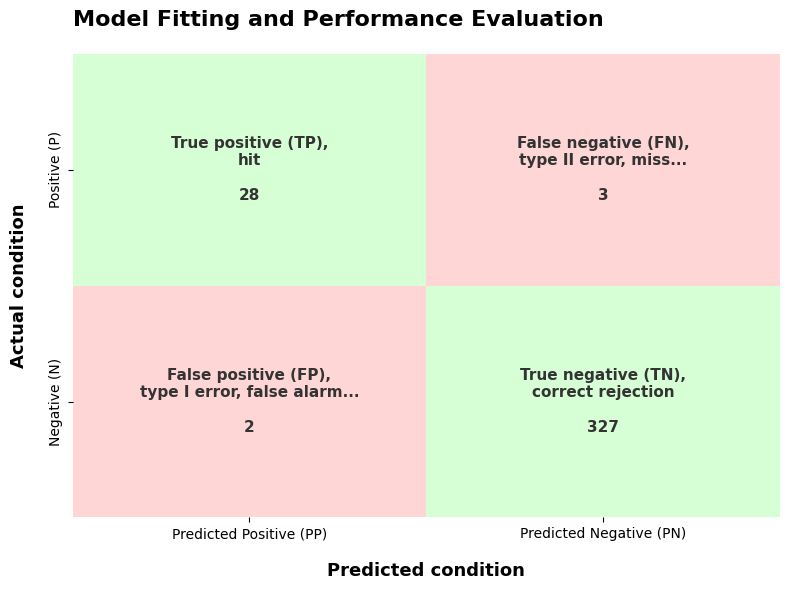

--- Detailed Performance Analysis ---
True Positives (Hit): 28
False Positives (Type I Error / False alarm): 2
False Negatives (Type II Error / Miss): 3
True Negatives (Correct rejection): 327

Precision: 0.9333
Recall (Sensitivity): 0.9032


In [51]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
from matplotlib.colors import ListedColormap

# Calculate the confusion matrix
# We set labels=[1, 0] to match the exact layout of the presentation slide, 
# where 'Positive' comes first (top/left) and 'Negative' is second (bottom/right).
cm = confusion_matrix(y_test, y_pred, labels=[1, 0])

# Extract True Positive, False Negative, False Positive, and True Negative
tp, fn, fp, tn = cm.ravel()

# Create descriptive annotations matching the terminology on the slide
annotations = np.array([
    [f"True positive (TP),\nhit\n\n{tp}", f"False negative (FN),\ntype II error, miss...\n\n{fn}"],
    [f"False positive (FP),\ntype I error, false alarm...\n\n{fp}", f"True negative (TN),\ncorrect rejection\n\n{tn}"]
])

# --- CRITICAL CHANGE HERE ---
# Create a layout matrix purely for color mapping:
# 1 represents Correct predictions (TP, TN) -> will be mapped to Green
# 0 represents Errors (FP, FN) -> will be mapped to Pink
color_layout = np.array([
    [1, 0], 
    [0, 1]
])

# Define custom colors closely matching the presentation slide
# Index 0 maps to Pink (#FFD6D6), Index 1 maps to Green (#D6FFD6)
custom_cmap = ListedColormap(['#FFD6D6', '#D6FFD6']) 

plt.figure(figsize=(8, 6))

# Plot the heatmap using color_layout for colors, and annotations for text
sns.heatmap(color_layout, annot=annotations, fmt="", cmap=custom_cmap, cbar=False,
            xticklabels=["Predicted Positive (PP)", "Predicted Negative (PN)"],
            yticklabels=["Positive (P)", "Negative (N)"],
            annot_kws={"size": 11, "weight": "bold", "color": "#333333"})

# Add titles and axis labels to match the slide structure
plt.title("Model Fitting and Performance Evaluation", pad=20, fontsize=16, fontweight="bold", loc="left")
plt.xlabel("Predicted condition", fontsize=13, labelpad=15, fontweight="bold")
plt.ylabel("Actual condition", fontsize=13, labelpad=15, fontweight="bold")

# Adjust layout to prevent clipping
plt.tight_layout()
plt.show()

# --- Print Detailed Metrics ---
print("--- Detailed Performance Analysis ---")
print(f"True Positives (Hit): {tp}")
print(f"False Positives (Type I Error / False alarm): {fp}")
print(f"False Negatives (Type II Error / Miss): {fn}")
print(f"True Negatives (Correct rejection): {tn}")

# Calculate Precision and Recall safely
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
print(f"\nPrecision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")


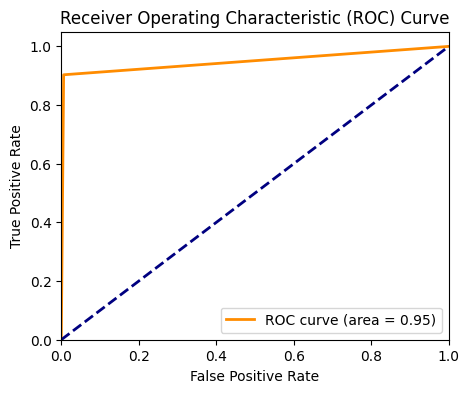

In [47]:
from sklearn.metrics import roc_curve, auc

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

## Part 4 — Visualizing the network

A quick visualization can help students connect the code (layers, weights) to the conceptual diagram shown in the slides.

In [41]:
# # Network Visualization

# from sklearn.datasets import make_classification

# # Generate a 10D dataset
# X, y = make_classification(n_samples=200, n_features=10, n_informative=10, n_redundant=0, random_state=42)

# # Split the dataset into training and test sets
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Initialize the network
# net = FNN([12,6], epochs=1000, learning_rate=0.01)

# # Train the network
# net.fit(X_train, y_train)

# # Visualize the network
# fig, _ = visualize_network(net, figsize=(6, 6))
# fig.savefig('neural_network.pdf')

ValueError: Found input variables with inconsistent numbers of samples: [40, 360]